In [30]:
#import
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from prettytable import PrettyTable


In [31]:
#read
df = pd.read_csv("../dataset/Electric_Vehicle_Population_Data.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,WA1E2AFY8R,Thurston,Olympia,WA,98512.0,2024,AUDI,Q5 E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,23.0,0.0,22.0,263239938,POINT (-122.90787 46.9461),PUGET SOUND ENERGY INC,5.306701e+10
1,WAUUPBFF4J,Yakima,Wapato,WA,98951.0,2018,AUDI,A3,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,16.0,0.0,15.0,318160860,POINT (-120.42083 46.44779),PACIFICORP,5.307794e+10
2,1N4AZ0CP0F,King,Seattle,WA,98125.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,46.0,184963586,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
3,WA1VAAGE5K,King,Kent,WA,98031.0,2019,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,204.0,0.0,11.0,259426821,POINT (-122.17743 47.41185),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,7SAXCAE57N,Snohomish,Bothell,WA,98021.0,2022,TESLA,MODEL X,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,1.0,208182236,POINT (-122.18384 47.8031),PUGET SOUND ENERGY INC,5.306105e+10


In [32]:
#check dataset
df.info()
df.describe(include="all")
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264628 entries, 0 to 264627
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         264628 non-null  object 
 1   County                                             264619 non-null  object 
 2   City                                               264619 non-null  object 
 3   State                                              264628 non-null  object 
 4   Postal Code                                        264619 non-null  float64
 5   Model Year                                         264628 non-null  int64  
 6   Make                                               264628 non-null  object 
 7   Model                                              264628 non-null  object 
 8   Electric Vehicle Type                              264628 non-null  object

VIN (1-10)                                             0
County                                                 9
City                                                   9
State                                                  0
Postal Code                                            9
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         4
Base MSRP                                              4
Legislative District                                 659
DOL Vehicle ID                                         0
Vehicle Location                                      17
Electric Utility                                       9
2020 Census Tract                                      9
dtype: int64

In [33]:
#check missing value
df.isna().sum()

VIN (1-10)                                             0
County                                                 9
City                                                   9
State                                                  0
Postal Code                                            9
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         4
Base MSRP                                              4
Legislative District                                 659
DOL Vehicle ID                                         0
Vehicle Location                                      17
Electric Utility                                       9
2020 Census Tract                                      9
dtype: int64

In [34]:
#drop missing value
df = df.dropna()

In [35]:
#fill missing => because using model year
df["Model Year"] = df["Model Year"].fillna(df["Model Year"].median())
df["Base MSRP"] = df["Base MSRP"].fillna(df["Base MSRP"].median())


In [36]:
#check duplicate => drop
df.duplicated().sum()
df = df.drop_duplicates()

In [37]:
#chuan hoa => year => int
df["Model Year"] = df["Model Year"].astype(int)


In [38]:
#chuan hoa => text
df["State"] = df["State"].str.strip()
df["City"] = df["City"].str.strip()

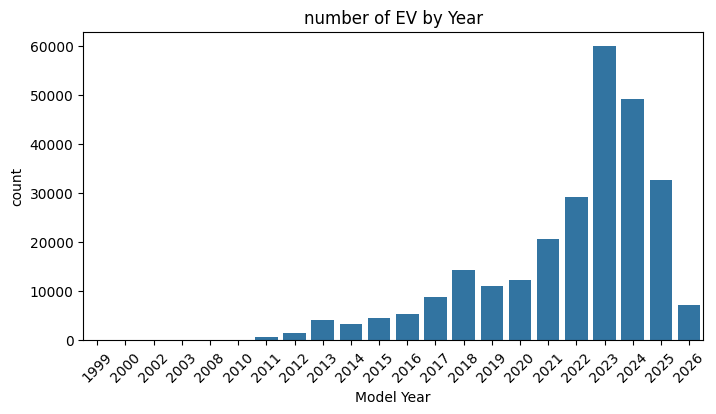

In [39]:
#EDA
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Model Year")
plt.title("number of EV by Year")
plt.xticks(rotation=45)
plt.show()

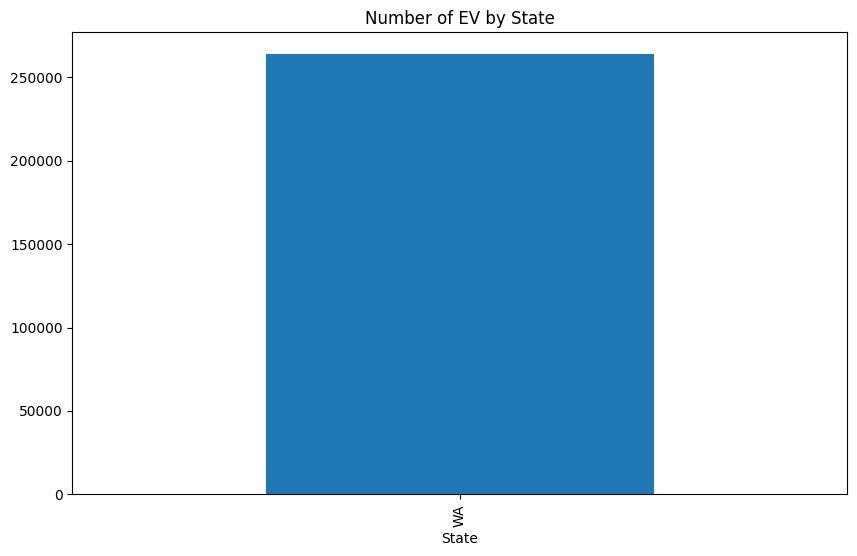

In [40]:
plt.figure(figsize=(10,6))
df["State"].value_counts().plot(kind="bar")
plt.title("Number of EV by State")
plt.show()


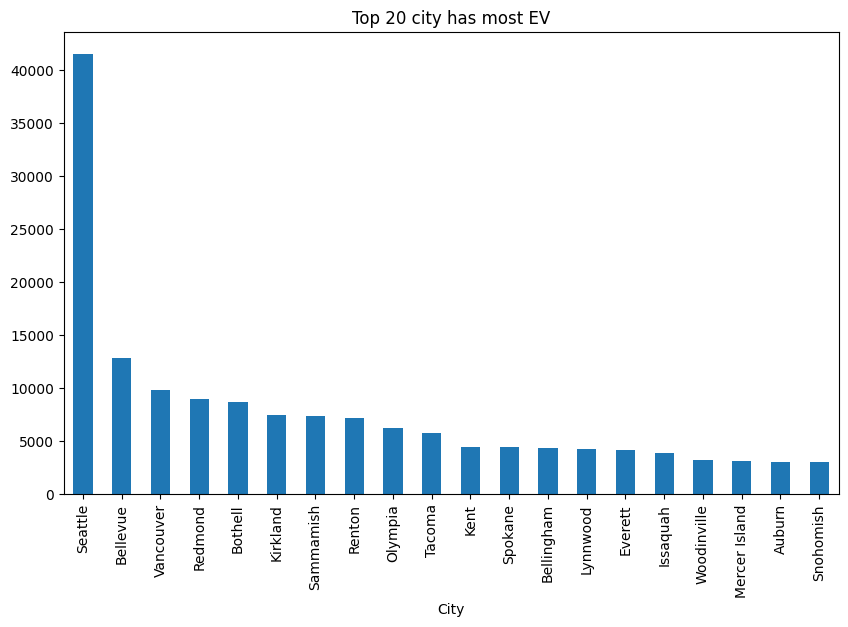

In [41]:
plt.figure(figsize=(10,6))
df["City"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 city has most EV")
plt.show()


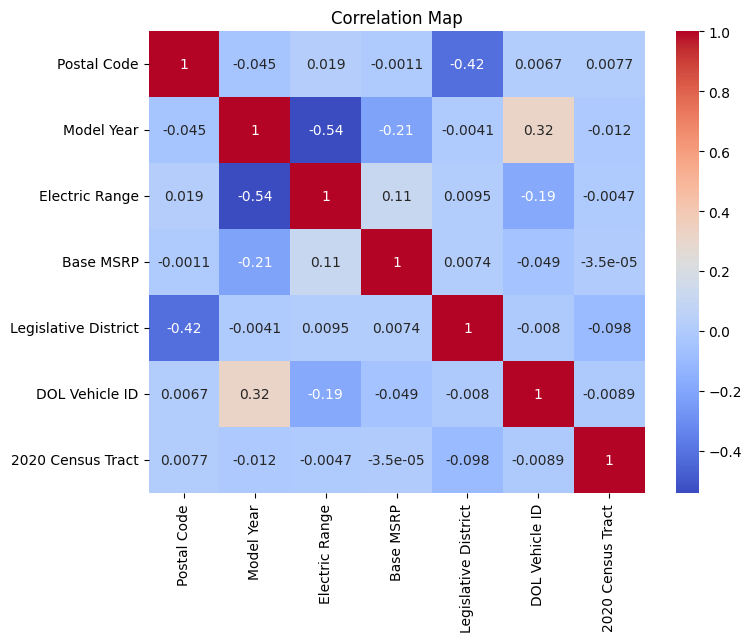

In [42]:
#corelation (numeric)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Map")
plt.show()


In [43]:
ev_year = df.groupby("Model Year").size().reset_index(name="EV_Count")
ev_year

,Model Year,EV_Count
0,1999,2
1,2000,8
2,2002,1
3,2003,1
4,2008,20
5,2010,22
6,2011,622
7,2012,1434
8,2013,4058
9,2014,3282


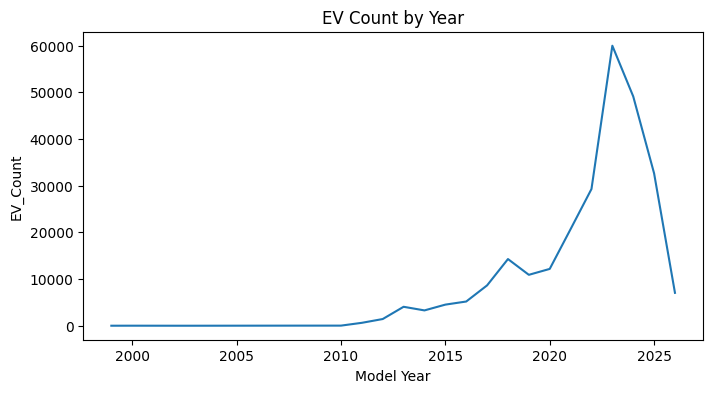

In [44]:
plt.figure(figsize=(8,4))
sns.lineplot(data=ev_year, x="Model Year",y = "EV_Count")
plt.title("EV Count by Year")
plt.show()

In [45]:
ev_state = df.groupby("State").size().reset_index(name="EV_Count")
ev_state.sort_values("EV_Count", ascending=False)

,State,EV_Count
0,WA,263957


In [46]:
ev_city = df.groupby("City").size().reset_index(name="EV_Count")
ev_city.sort_values("EV_Count", ascending=False).head(20)

,City,EV_Count
379,Seattle,41532
26,Bellevue,12843
452,Vancouver,9862
352,Redmond,9035
35,Bothell,8721
197,Kirkland,7463
374,Sammamish,7345
353,Renton,7234
302,Olympia,6212
424,Tacoma,5774


In [47]:


output_file_path = "../outputs/Electric_Vehicle_Population_Data_CLEANED_FINAL.csv"


df.to_csv(
    output_file_path, 
    index=False,        
    encoding='utf-8'
)


In [48]:
# ================================
# II. CLASSIFICATION BEV / PHEV
# ================================


In [49]:

df_clf = df.copy()

#only chose numeric and revelant
features = ["Model Year", "Base MSRP"]

X = df_clf[features]
y = df_clf["Electric Vehicle Type"]

# encode bev/phev label to 0/1
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# khoi tao model
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# table comparing
table = PrettyTable()
table.field_names = ["Model", "Accuracy", "Precision", "Recall", "F1"]

C:\Users\PC\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


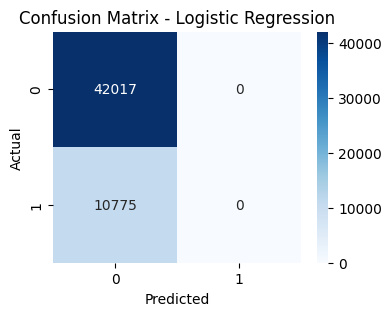

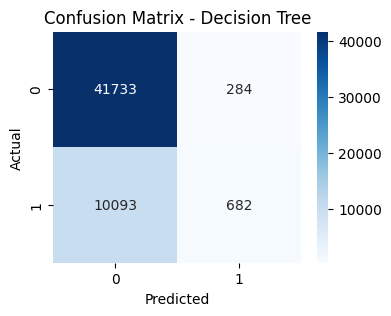

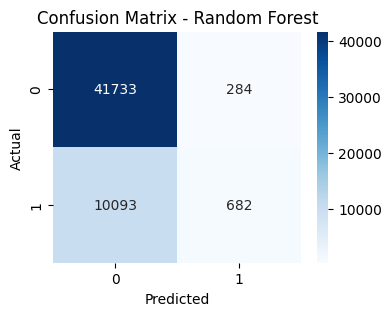

+---------------------+----------+-----------+--------+--------+
|        Model        | Accuracy | Precision | Recall |   F1   |
+---------------------+----------+-----------+--------+--------+
| Logistic Regression |  0.7959  |    0.0    |  0.0   |  0.0   |
|    Decision Tree    |  0.8034  |   0.706   | 0.0633 | 0.1162 |
|    Random Forest    |  0.8034  |   0.706   | 0.0633 | 0.1162 |
+---------------------+----------+-----------+--------+--------+


In [ ]:
# 3. Train and review model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    table.add_row([name, 
                   round(acc, 4),
                   round(pre, 4),
                   round(rec, 4),
                   round(f1, 4)
                  ])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# print
print(table)